In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from tensorflow import keras
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
diabetes = load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X, y = load_diabetes(return_X_y=True, as_frame=True)

print(X.head())

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFörsta targetvärden:")
print(y.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
X shape: (442, 10)
y shape: (442,)

Första targetvärden:
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (353, 10)
Test shape: (89, 10)


In [ ]:
n_cols = X_train.shape[1]
n_cols

model = Sequential([
    Input(shape=(n_cols, )),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,953 (7.63 KB)

 Trainable params: 1,953 (7.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
    )

In [7]:
training = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 31517.9336 - mae: 158.6417 - val_loss: 22471.2285 - val_mae: 134.0404
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31491.4531 - mae: 158.5617 - val_loss: 22445.1172 - val_mae: 133.9446
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31454.1445 - mae: 158.4441 - val_loss: 22406.3906 - val_mae: 133.8027
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31396.8125 - mae: 158.2673 - val_loss: 22347.0254 - val_mae: 133.5836
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31305.3086 - mae: 157.9889 - val_loss: 22253.5586 - val_mae: 133.2391
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31163.9902 - mae: 157.5531 - val_loss: 22108.7676 - val_mae: 132.7076
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30951.9004 - mae: 156.8882 - val_loss: 21889.8203 - val_mae: 131.9034
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30618.8730 - mae: 155.8790 - val_loss: 21568.5312 - val_mae: 

In [8]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test loss (MSE): 3054.1741
Test MAE: 45.6728


In [ ]:
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

print("Första 10 prediktioner:")
print(y_pred[:10])
print("\nFörsta 10 sanna värden:")
print(y_test.iloc[:10].values)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Första 10 prediktioner:
[161.80003  168.21886  154.12831  285.6221   149.17403  121.80724
 226.25056  198.30858  112.672775 129.69371 ]

Första 10 sanna värden:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]


In [11]:
results_df = pd.DataFrame({
    "True value": y_test.reset_index(drop=True),
    "Predicted value": y_pred
})

results_df["Residual"] = results_df["True value"] - results_df["Predicted value"]

print(results_df.head(10))

   True value  Predicted value   Residual
0       219.0       161.800034  57.199966
1        70.0       168.218857 -98.218857
2       202.0       154.128311  47.871689
3       230.0       285.622101 -55.622101
4       111.0       149.174026 -38.174026
5        84.0       121.807243 -37.807243
6       242.0       226.250565  15.749435
7       272.0       198.308578  73.691422
8        94.0       112.672775 -18.672775
9        96.0       129.693710 -33.693710


In [13]:
print(training.history.keys())

print("\nFörsta fem train loss-värden:")
print(training.history["loss"][:5])

print("\nFörsta fem validation loss-värden:")
print(training.history["val_loss"][:5])

print("\nFörsta fem train MAE-värden:")
print(training.history["mae"][:5])

print("\nFörsta fem validation MAE-värden:")
print(training.history["val_mae"][:5])

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

Första fem train loss-värden:
[31517.93359375, 31491.453125, 31454.14453125, 31396.8125, 31305.30859375]

Första fem validation loss-värden:
[22471.228515625, 22445.1171875, 22406.390625, 22347.025390625, 22253.55859375]

Första fem train MAE-värden:
[158.6417236328125, 158.56167602539062, 158.44412231445312, 158.267333984375, 157.98887634277344]

Första fem validation MAE-värden:
[134.04039001464844, 133.9446258544922, 133.8026580810547, 133.58363342285156, 133.2391357421875]


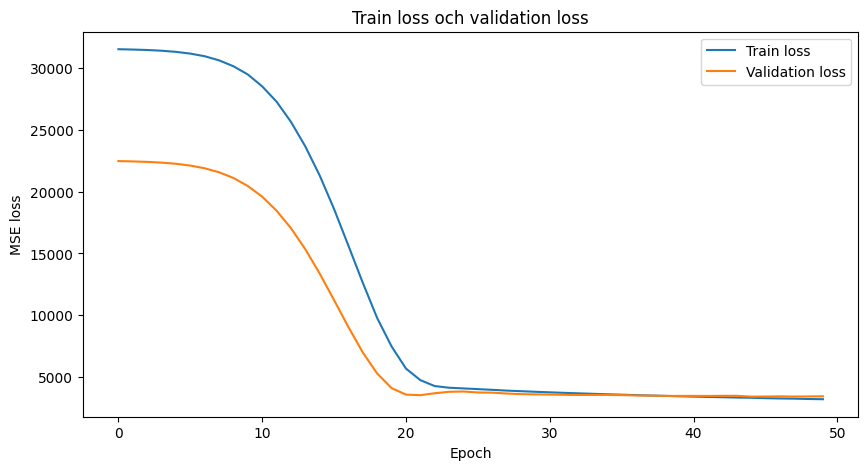

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(training.history["loss"], label="Train loss")
plt.plot(training.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Train loss och validation loss")
plt.legend()
plt.show()

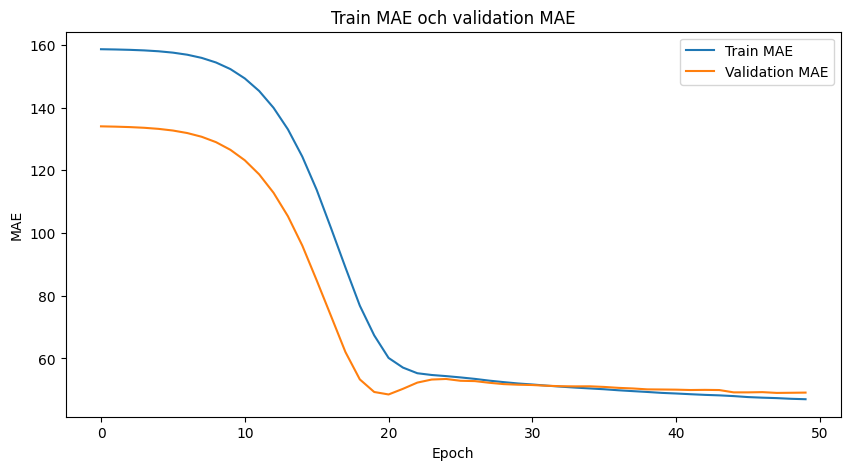

In [15]:
plt.figure(figsize=(10,5))

plt.plot(training.history["mae"], label="Train MAE")
plt.plot(training.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Train MAE och validation MAE")
plt.legend()
plt.show()

C:\Users\joaki\AppData\Local\Temp\ipykernel_71812\629539780.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


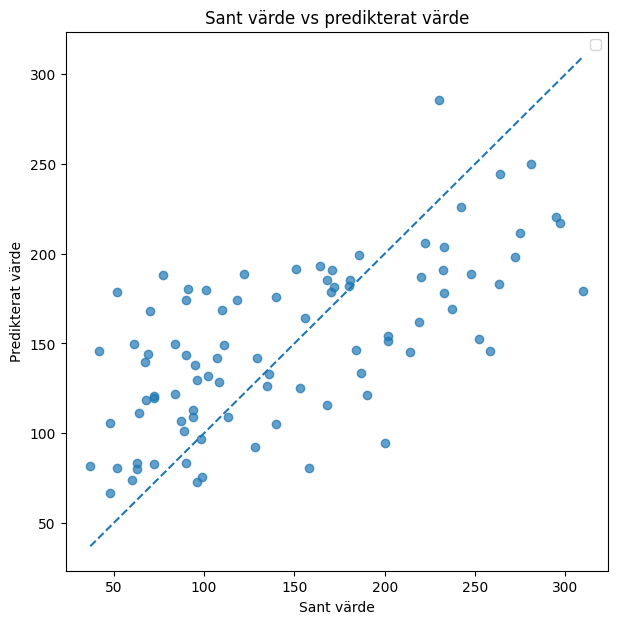

In [16]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.7)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Sant värde")
plt.ylabel("Predikterat värde")
plt.title("Sant värde vs predikterat värde")
plt.legend()
plt.show()

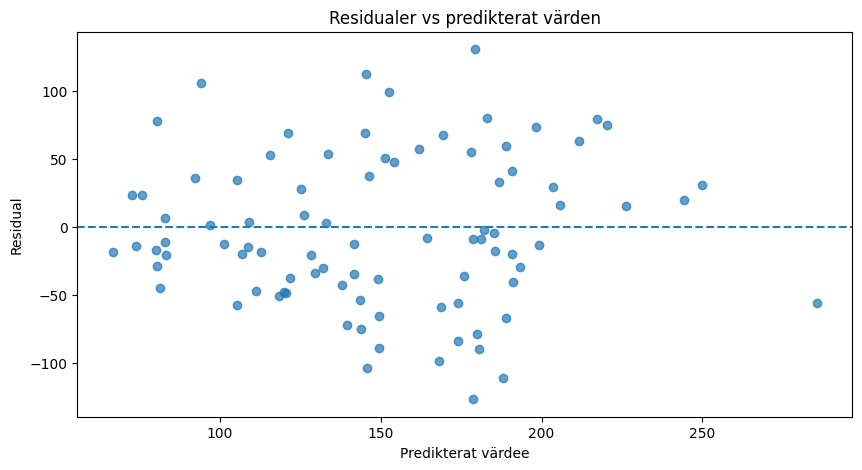

In [17]:
plt.figure(figsize=(10, 5))

plt.scatter(results_df["Predicted value"], results_df["Residual"], alpha=0.7)


plt.axhline(0, linestyle="--")

plt.xlabel("Predikterat värdee")
plt.ylabel("Residual")
plt.title("Residualer vs predikterat värden")
plt.show()

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)


nn_mae = mean_absolute_error(y_test, y_pred)
nn_mse = mean_squared_error(y_test, y_pred)
nn_r2 = r2_score(y_test, y_pred)


comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "MAE": [linear_mae, nn_mae],
    "MSE": [linear_mse, nn_mse],
    "R2": [linear_r2, nn_r2],
})


print(comparison_df)

               Model        MAE          MSE        R2
0  Linear Regression  42.794095  2900.193628  0.452603
1     Neural Network  45.672766  3054.173995  0.423540
